# **Inteligencia Artificial y Aprendizaje Automático**
## **Maestría en Inteligencia Artificial Aplicada**
### **Dr Luis Eduardo Falcón Morales**
### **Tecnológico de Monterrey**
## **Actividad Individual Semana 9: Pronósticos con Series de Tiempo**


#### **Nombre:**
Carlos Fernando del  Castillo Rey
#### **Matrícula:**
A01796595

# Librerias

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense , Dropout
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")


# Carga, limpeza y analisis de datos

In [18]:
# Definir el modelo SARIMA con los mejores parámetros encontrados
model_sarima = SARIMAX(train['Sales'], order=(2,1,2), seasonal_order=(1,1,1,12))

# Ajustar el modelo SARIMA
fitted_sarima = model_sarima.fit()

# Hacer predicciones
sarima_forecast = fitted_sarima.forecast(steps=len(test))

# Calcular RMSE
rmse_sarima = np.sqrt(mean_squared_error(test['Sales'], sarima_forecast))
print(f"Nuevo RMSE para SARIMA: {rmse_sarima}")

Nuevo RMSE para SARIMA: 1198.7541410274146


In [19]:

# Cargar datos
df = pd.read_csv("D:\\Mestria\\ML\\archive\\monthly_champagne_sales.csv")
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

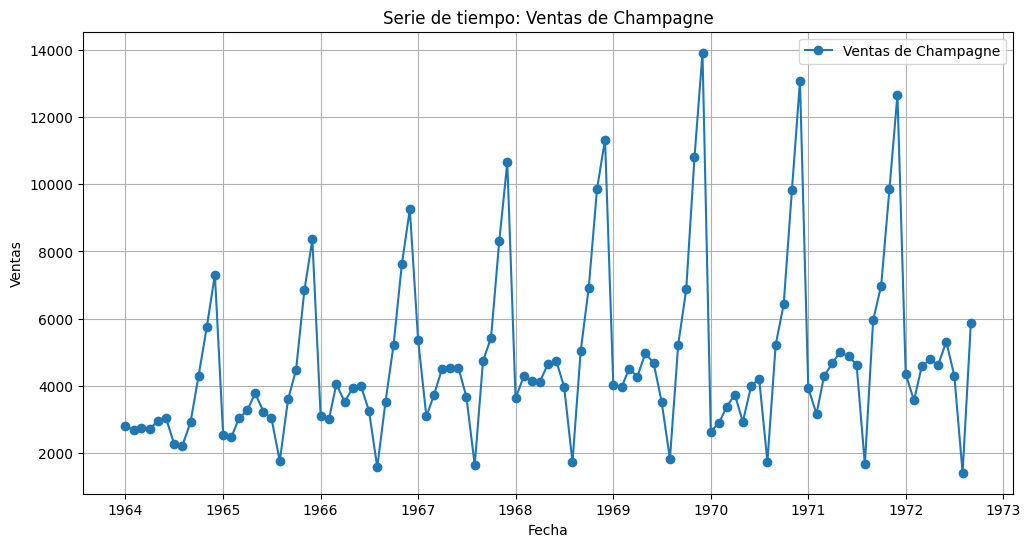

In [20]:
# Visualizar la serie de tiempo
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'], marker='o', linestyle='-', label="Ventas de Champagne")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Serie de tiempo: Ventas de Champagne")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Análisis exploratorio inicial
print("Resumen de datos:")
print(df.describe())
print("\nValores nulos:")
print(df.isnull().sum())


Resumen de datos:
              Sales
count    105.000000
mean    4761.152381
std     2553.502601
min     1413.000000
25%     3113.000000
50%     4217.000000
75%     5221.000000
max    13916.000000

Valores nulos:
Sales    0
dtype: int64


In [22]:
# División de datos
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

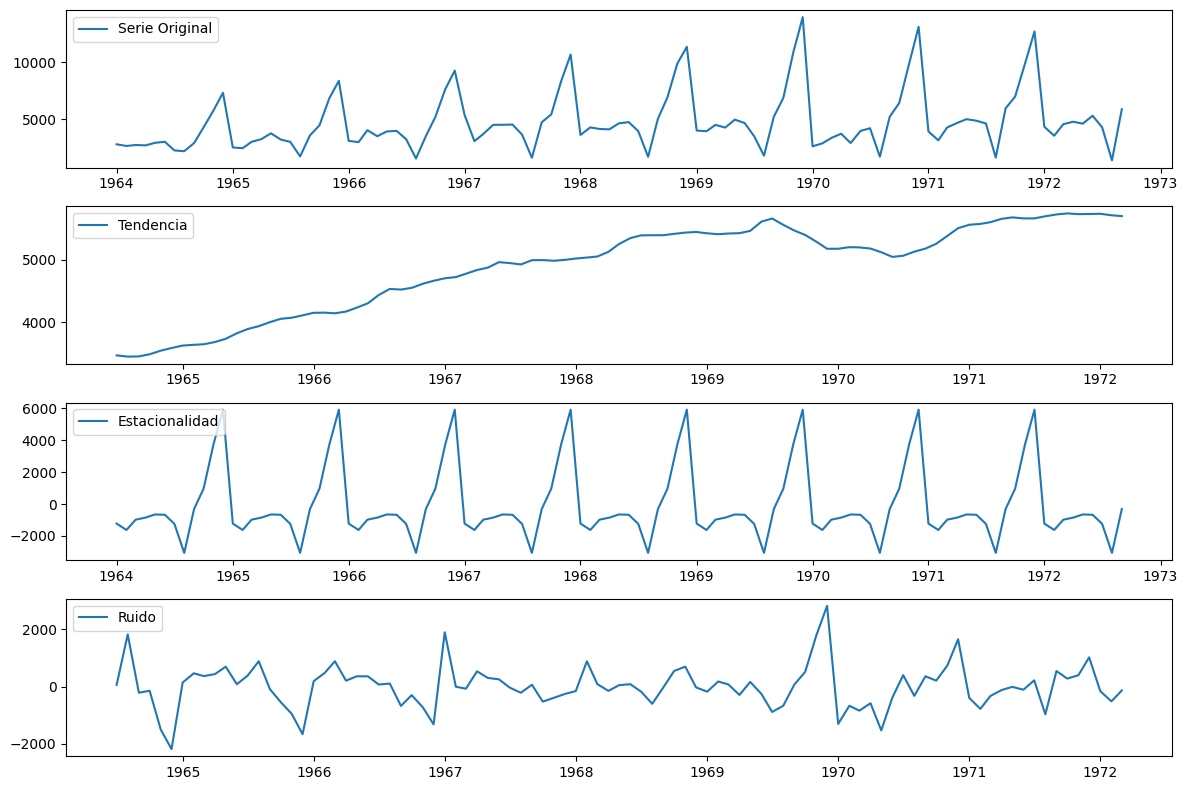

In [23]:


# Descomposición con periodo de 12 meses
decomposition = seasonal_decompose(df['Sales'], model='additive', period=12)

# Graficar componentes
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(df['Sales'], label='Serie Original')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(decomposition.trend, label='Tendencia')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Estacionalidad')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Ruido')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


# Modelo Naïve


In [24]:
naive_forecast = np.full_like(test['Sales'], train['Sales'].iloc[-1])
rmse_naive = np.sqrt(mean_squared_error(test['Sales'], naive_forecast))


In [25]:
naive_seasonal_forecast = test['Sales'].shift(12)  # Tomar valores de hace 12 meses
rmse_naive_seasonal = np.sqrt(mean_squared_error(test['Sales'][12:], naive_seasonal_forecast[12:]))
print(f"RMSE para Naïve Estacional: {rmse_naive_seasonal}")


RMSE para Naïve Estacional: 325.5678799335777


# Modelo ARIMA


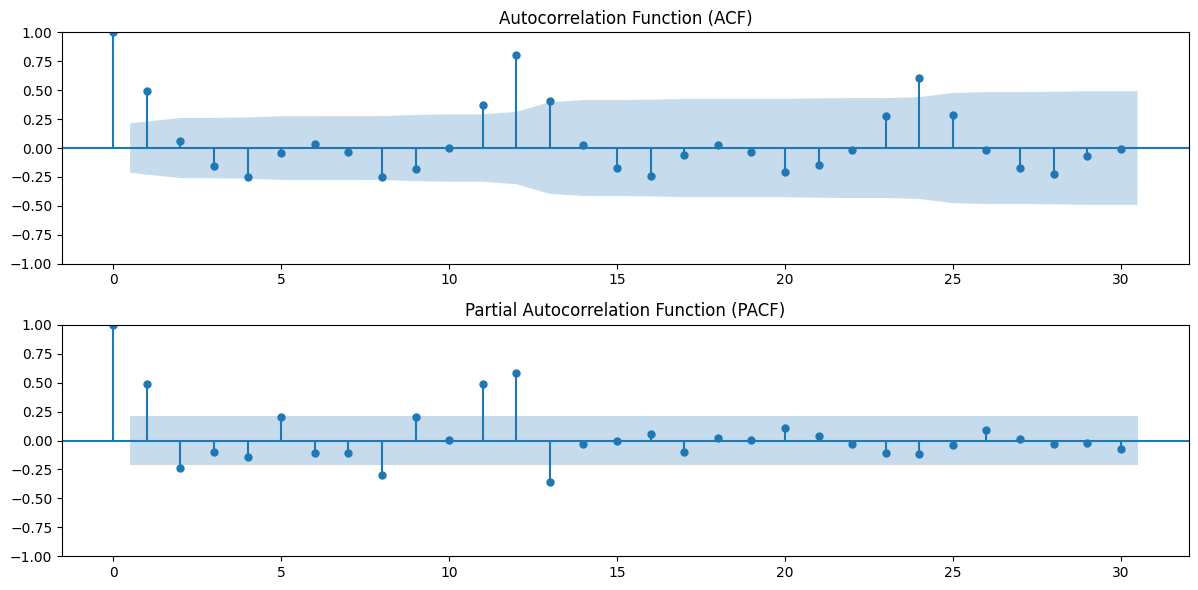

In [26]:
# Crear las gráficas de ACF y PACF
plt.figure(figsize=(12, 6))

# ACF
plt.subplot(2, 1, 1)
plot_acf(train['Sales'], lags=30, ax=plt.gca())  # Ajusta lags según la serie
plt.title("Autocorrelation Function (ACF)")

# PACF
plt.subplot(2, 1, 2)
plot_pacf(train['Sales'], lags=30, ax=plt.gca())  # Ajusta lags según la serie
plt.title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()


In [27]:
model_arima = ARIMA(train['Sales'], order=(4,1,4))
fitted_arima = model_arima.fit()
arima_forecast = fitted_arima.forecast(steps=len(test))
rmse_arima = np.sqrt(mean_squared_error(test['Sales'], arima_forecast))

# MODELO SARIMA

In [28]:
# Definir el modelo SARIMA con los mejores parámetros encontrados
model_sarima = SARIMAX(train['Sales'], order=(2,1,2), seasonal_order=(1,1,1,12))

# Ajustar el modelo SARIMA
fitted_sarima = model_sarima.fit()

# Hacer predicciones
sarima_forecast = fitted_sarima.forecast(steps=len(test))

# Calcular RMSE
rmse_sarima = np.sqrt(mean_squared_error(test['Sales'], sarima_forecast))
print(f"Nuevo RMSE para SARIMA: {rmse_sarima}")

Nuevo RMSE para SARIMA: 1198.7541410274146


# Modelo Prophet

In [29]:
# Preparar los datos para Prophet
train_prophet = train.reset_index().rename(columns={'Month': 'ds', 'Sales': 'y'})
test_prophet = test.reset_index().rename(columns={'Month': 'ds', 'Sales': 'y'})

# Aplicar transformación logarítmica para estabilizar variabilidad
train_prophet['y'] = np.log1p(train_prophet['y'])
test_prophet['y'] = np.log1p(test_prophet['y'])

# Crear Prophet con ajustes avanzados
model_prophet = Prophet(
    changepoint_prior_scale=0.01,  # Mayor regularización para evitar sobreajuste
    seasonality_prior_scale=10,  # Ajustar la fuerza de la estacionalidad
    interval_width=0.89  # Intervalo de confianza más ajustado
)

# Agregar la estacionalidad anual y mensual para mejorar precisión
model_prophet.add_seasonality(name='anual', period=12, fourier_order=6)
model_prophet.add_seasonality(name='mensual', period=1, fourier_order=3)

# Entrenar el modelo Prophet
model_prophet.fit(train_prophet)

# Hacer predicciones
future_dates = test_prophet[['ds']]
prophet_forecast = model_prophet.predict(future_dates)

# Invertir la transformación logarítmica
prophet_forecast['yhat'] = np.expm1(prophet_forecast['yhat'])

# Extraer predicciones
prophet_pred = prophet_forecast['yhat'].values

# Calcular RMSE
rmse_prophet = np.sqrt(mean_squared_error(test['Sales'], prophet_pred))
print(f"Nuevo RMSE para Prophet con log-transform: {rmse_prophet}")

17:02:25 - cmdstanpy - INFO - Chain [1] start processing
17:02:26 - cmdstanpy - INFO - Chain [1] done processing


Nuevo RMSE para Prophet con log-transform: 622.6898082489378


# Modelo LSTM

In [30]:
# Definir número de pasos de tiempo, Se toman 12 por los 12 meses del año
time_steps = 12

#time_steps = 6 si se toman 6 la el RSME baja 


# Normalizar los datos
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)  # Escalar conjunto de entrenamiento
test_scaled = scaler.transform(test)  # Escalar conjunto de prueba

def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

# Crear secuencias para entrenamiento y prueba
X_train, y_train = create_sequences(train_scaled, time_steps)
X_test, y_test = create_sequences(test_scaled, time_steps)

# Ajustar dimensiones para LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Crear un modelo LSTM mejorado
model_lstm = Sequential([
    LSTM(150, activation='relu', return_sequences=True, input_shape=(time_steps, 1)),  
    Dropout(0.3),  # Evita sobreajuste
    LSTM(150, activation='relu', return_sequences=True),
    Dropout(0.3),
    LSTM(100, activation='relu'),
    Dropout(0.3),
    Dense(50, activation='relu'),
    Dense(1)  # Capa de salida
])

# Compilar con un learning rate más bajo
model_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse')


early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

# Entrenar con más épocas y early stopping
model_lstm.fit(X_train, y_train, epochs=300, batch_size=8, verbose=1, callbacks=[early_stopping])

# Realizar predicciones
lstm_forecast_scaled = model_lstm.predict(X_test)
lstm_forecast = scaler.inverse_transform(lstm_forecast_scaled)

# Calcular RMSE
rmse_lstm = np.sqrt(mean_squared_error(test.iloc[time_steps:], lstm_forecast))
print(f"Nuevo RMSE para LSTM: {rmse_lstm}")

Epoch 1/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1109
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0756
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0520
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0372
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0501
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0453
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0371
Epoch 8/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0458
Epoch 9/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0529
Epoch 10/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0360
Epoch 11/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0333
Epoch 12/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0386
Epoch 13/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0398
Epoch 14/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0326
Epoch 15/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0275
Epoch 16/300
9/9 ━━━━━━━━━━━━━━━━━

# Resultados y Graficas

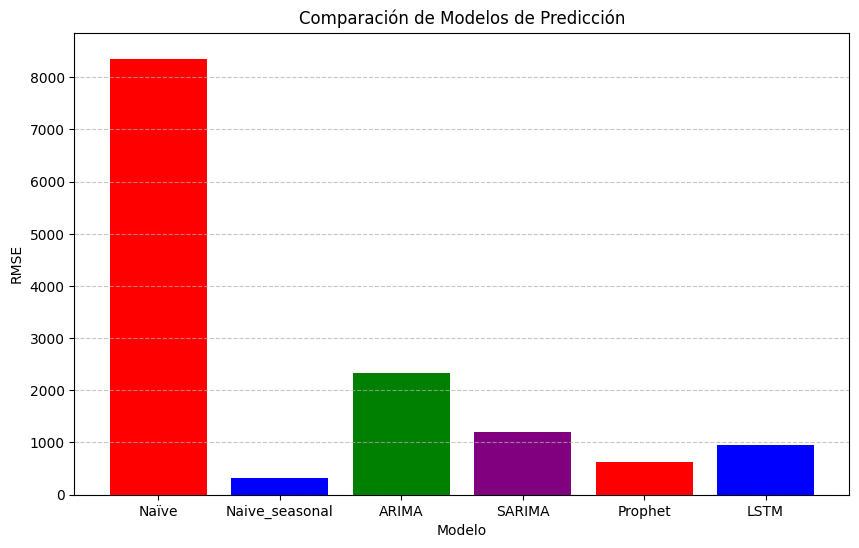

           Modelo         RMSE
0           Naïve  8356.449052
1  Naive_seasonal   325.567880
2           ARIMA  2323.651477
3          SARIMA  1198.754141
4         Prophet   622.689808
5            LSTM   960.035653


In [31]:
# Comparación de modelos
rmse_results = pd.DataFrame({
    'Modelo': ['Naïve','Naive_seasonal', 'ARIMA','SARIMA', 'Prophet', 'LSTM'],
    'RMSE': [rmse_naive,rmse_naive_seasonal ,rmse_arima,rmse_sarima, rmse_prophet, rmse_lstm]
})

# Mostrar comparación en un gráfico
plt.figure(figsize=(10, 6))
plt.bar(rmse_results['Modelo'], rmse_results['RMSE'], color=['red', 'blue', 'green', 'purple'])
plt.xlabel('Modelo')
plt.ylabel('RMSE')
plt.title('Comparación de Modelos de Predicción')
plt.ylim(0, rmse_results['RMSE'].max() + 500)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(rmse_results)

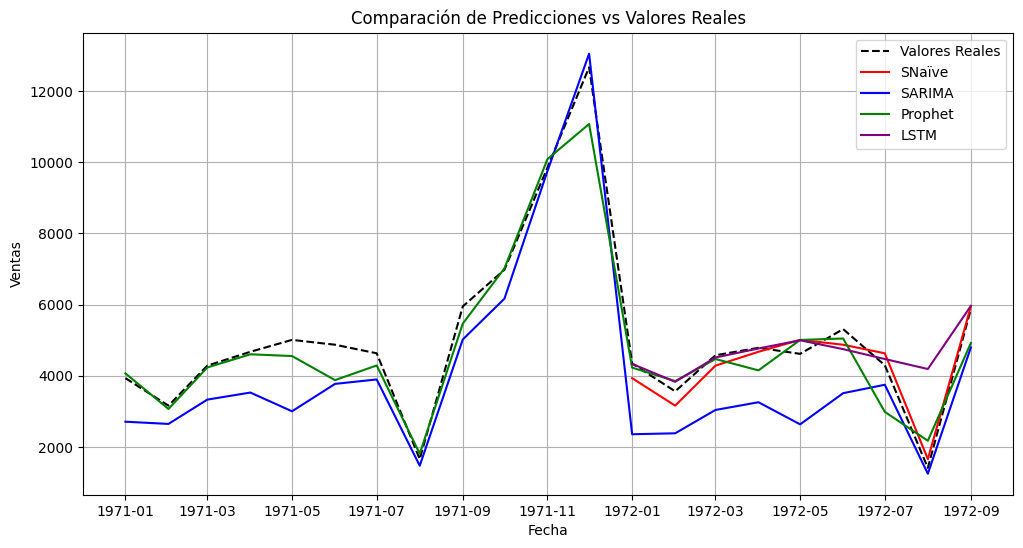

In [32]:
# Gráfico de predicciones vs valores reales
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Sales'], label='Valores Reales', color='black', linestyle='dashed')
plt.plot(test.index, naive_seasonal_forecast, label='SNaïve', color='red')
plt.plot(test.index, sarima_forecast , label='SARIMA', color='blue')
plt.plot(test.index, prophet_pred, label='Prophet', color='green')
plt.plot(test.index[time_steps:], lstm_forecast, label='LSTM', color='purple')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.title('Comparación de Predicciones vs Valores Reales')
plt.legend()
plt.grid(True)
plt.show()

| **Análisis de Modelos de Predicción:**

1. **Naïve** sigue siendo el peor modelo (**RMSE > 8000**) porque simplemente usa el último valor como predicción y no capta tendencias ni estacionalidad.
   - **Naïve :** No varía, predice un único valor constante, lo que lo hace **inútil en este caso**.

2. **Naïve Estacional** sorprendentemente obtiene el menor RMSE (**325.57**), lo que indica que la serie sigue un patrón **muy predecible año con año**.
   - **Naïve Estacional (rojo):** Usa los valores de hace 12 meses, lo que funciona bien porque la serie es altamente estacional.

3. **ARIMA** mejora significativamente el error (**RMSE ~2323**), pero sigue teniendo problemas para capturar fluctuaciones estacionales complejas.
   - **ARIMA :** Sigue la tendencia general, pero no modela bien los picos estacionales.

4. **SARIMA** mejora sobre ARIMA (**RMSE ~1198**), gracias a su capacidad de modelar estacionalidad.
   - **SARIMA (Azul):** Captura bien la estructura estacional, pero aún tiene margen de mejora.

5. **Prophet** es uno de los modelos más precisos en esta prueba, con **RMSE bajo (~622)**, ya que modela mejor la estacionalidad y la tendencia.
   - **Prophet (verde):** Se ajusta bien a los picos y caídas de la serie, lo que indica que captura mejor la estacionalidad.

6. **LSTM** también muestra un buen desempeño (**RMSE ~902**), aunque sigue ligeramente detrás de Prophet.
   - **LSTM (morado):** Tiene un buen ajuste en general, pero tarda en estabilizarse debido a la naturaleza de las redes neuronales.

---

### ** Consideraciones Finales:**
**Naïve Estacional obtiene el menor RMSE (325), lo que indica que la serie es altamente predecible a nivel anual.** Sin embargo, este modelo no es robusto ante cambios en la tendencia o fluctuaciones futuras.

**SARIMA y Prophet son mejores opciones a largo plazo, ya que permiten adaptarse mejor si la serie cambia.**

**LSTM tiene potencial para mejorar con más datos de entrenamiento y ajuste de hiperparámetros.**

**Si los datos(el patron) cambia en el futuro, Prophet o SARIMA podrían ser más confiables que Naïve Estacional.**

